In [ ]:
# Sistem Pendukung Keputusan Pemilihan Rumah Layak Dibeli Menggunakan Prediksi Harga Berbasis Random Forest dan Metode TOPSIS

## UAS Sistem Pendukung Keputusan dan Machine Learning

# Anggota Kelompok

## Kelompok 2

| No | Nama |
|----|------|
| 1 | Anggi Dwi Saputra |
| 2 | Esa Rizky Filiansyah|

# Dataset

Dataset yang digunakan pada penelitian ini adalah:

### Harga Rumah Jabodetabek Dataset

https://www.kaggle.com/datasets/nafisbarizki/daftar-harga-rumah-jabodetabek

Dataset ini berisi informasi mengenai berbagai karakteristik rumah yang berada di wilayah Jabodetabek (Jakarta, Bogor, Depok, Tangerang, dan Bekasi). Data diperoleh dari platform properti online dan mencakup berbagai atribut yang memengaruhi harga rumah.

Karakteristik yang tersedia dalam dataset meliputi:

- Harga rumah
- Kota/Kabupaten
- Luas tanah
- Luas bangunan
- Jumlah kamar tidur
- Jumlah kamar mandi
- Kapasitas garasi
- Jumlah lantai
- Sertifikat kepemilikan
- Fasilitas pendukung lainnya

Jumlah Data:
- ±3.500 data rumah

Jumlah Fitur:
- ±27 atribut

Target:
- Price / Price in Rp (Harga Rumah)

Alasan Pemilihan Dataset:
- Menggunakan data properti Indonesia sehingga lebih relevan dengan kondisi pasar lokal.
- Memiliki jumlah data yang cukup besar untuk proses pelatihan model Machine Learning.
- Memiliki banyak atribut yang dapat digunakan sebagai kriteria dalam proses rekomendasi rumah.
- Cocok untuk implementasi Random Forest dalam prediksi harga rumah.
- Cocok untuk implementasi Fuzzy Logic dan TOPSIS dalam proses penilaian dan perangkingan rumah terbaik.

Manfaat Dataset:
Dataset ini memungkinkan sistem untuk memprediksi harga rumah berdasarkan spesifikasi properti serta memberikan rekomendasi rumah yang paling layak dibeli berdasarkan berbagai kriteria yang telah ditentukan.

# Machine Learning

Pada penelitian ini digunakan algoritma **Random Forest Regressor** untuk melakukan prediksi harga rumah berdasarkan karakteristik properti yang terdapat pada dataset Harga Rumah Jabodetabek.

Random Forest merupakan algoritma Machine Learning berbasis ensemble learning yang bekerja dengan membangun banyak pohon keputusan (Decision Tree) dan menggabungkan hasil prediksi dari seluruh pohon untuk menghasilkan prediksi yang lebih akurat dan stabil.

Metode ini dipilih karena mampu menangani data dengan jumlah atribut yang cukup banyak, mengurangi risiko overfitting, serta memiliki performa yang baik pada kasus prediksi harga properti.

---

## Tujuan Penggunaan Random Forest

1. Memprediksi harga rumah berdasarkan karakteristik properti.
2. Mengetahui faktor-faktor yang paling berpengaruh terhadap harga rumah.
3. Menghasilkan estimasi harga yang dapat digunakan sebagai salah satu kriteria dalam proses rekomendasi rumah.

---

## Input Model

Beberapa fitur yang digunakan sebagai variabel prediktor antara lain:

- Luas Tanah
- Luas Bangunan
- Jumlah Kamar Tidur
- Jumlah Kamar Mandi
- Kapasitas Garasi
- Jumlah Lantai
- Lokasi/Kota

---

## Output Model

Output yang dihasilkan oleh model Random Forest adalah:

### Prediksi Harga Rumah

Contoh:

| Rumah | Harga Prediksi |
|---------|---------|
| Rumah A | Rp 850.000.000 |
| Rumah B | Rp 1.250.000.000 |
| Rumah C | Rp 950.000.000 |

Hasil prediksi harga ini selanjutnya digunakan sebagai salah satu kriteria dalam proses penilaian dan perangkingan rumah menggunakan Fuzzy Logic dan TOPSIS.

---

## Tahapan Machine Learning

1. Data Collection
2. Data Preprocessing
3. Feature Selection
4. Data Splitting (Training dan Testing)
5. Training Model Random Forest
6. Evaluasi Model
7. Prediksi Harga Rumah

---

## Evaluasi Model

Kinerja model dievaluasi menggunakan beberapa metrik evaluasi regresi, yaitu:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-Squared (R² Score)

Semakin kecil nilai MAE dan RMSE serta semakin mendekati 1 nilai R², maka semakin baik performa model dalam memprediksi harga rumah.

---

## Alur Machine Learning

Dataset Harga Rumah Jabodetabek
↓
Preprocessing Data
↓
Feature Selection
↓
Train Test Split
↓
Random Forest Regressor
↓
Prediksi Harga Rumah
↓
Evaluasi Model
↓
Hasil Prediksi

In [ ]:
# ==========================================================
# INSTALL LIBRARY
# ==========================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib scikit-fuzzy

In [ ]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import joblib
import os

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import randint

import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Dataset/jabodetabek_house_price.csv")

print(df.columns.tolist())

['url', 'price_in_rp', 'title', 'address', 'district', 'city', 'lat', 'long', 'facilities', 'property_type', 'ads_id', 'bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'carports', 'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms', 'floors', 'building_age', 'year_built', 'property_condition', 'building_orientation', 'garages', 'furnishing']


In [ ]:
# ==========================================================
# INFORMASI DATASET
# ==========================================================

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   3553 non-null   object 
 1   price_in_rp           3553 non-null   float64
 2   title                 3553 non-null   object 
 3   address               3553 non-null   object 
 4   district              3553 non-null   object 
 5   city                  3553 non-null   object 
 6   lat                   3553 non-null   float64
 7   long                  3553 non-null   float64
 8   facilities            3553 non-null   object 
 9   property_type         3552 non-null   object 
 10  ads_id                3549 non-null   object 
 11  bedrooms              3519 non-null   float64
 12  bathrooms             3524 non-null   float64
 13  land_size_m2          3551 non-null   float64
 14  building_size_m2      3551 non-null   float64
 15  carports             

,price_in_rp,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,garages
count,3.553000e+03,3553.000000,3553.000000,3519.000000,3524.000000,3551.000000,3551.000000,3553.000000,3553.000000,3553.000000,3547.000000,2108.000000,2108.000000,3553.000000
mean,4.191685e+09,-6.324721,106.792881,3.326513,2.624858,204.806815,186.587440,1.197861,0.496482,0.370391,1.764590,3.880930,2018.137097,0.708978
std,1.375067e+10,0.129245,0.172159,2.672148,2.696497,402.127746,248.443471,1.114996,0.685723,0.536024,0.637349,7.603708,7.641448,1.311879
min,4.200000e+07,-6.894828,106.402315,1.000000,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1870.000000,0.000000
25%,8.000000e+08,-6.397933,106.687295,2.000000,2.000000,75.000000,65.500000,1.000000,0.000000,0.000000,1.000000,0.000000,2016.000000,0.000000
50%,1.500000e+09,-6.300733,106.799954,3.000000,2.000000,108.000000,112.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2021.000000,0.000000
75%,3.590000e+09,-6.231754,106.874766,4.000000,3.000000,192.000000,208.000000,2.000000,1.000000,1.000000,2.000000,6.000000,2022.000000,1.000000
max,5.800000e+11,-6.102478,109.771691,99.000000,99.000000,8000.000000,6000.000000,15.000000,7.000000,5.000000,5.000000,152.000000,2052.000000,50.000000


In [ ]:
# ==========================================================
# CEK MISSING VALUE
# ==========================================================

missing = pd.DataFrame({

    "Missing": df.isnull().sum(),

    "Persentase (%)":
    round(
        df.isnull().sum()/len(df)*100,
        2
    )

})

missing.sort_values(
    by="Missing",
    ascending=False
)

,Missing,Persentase (%)
building_orientation,1647,46.36
year_built,1445,40.67
building_age,1445,40.67
furnishing,387,10.89
property_condition,246,6.92
certificate,141,3.97
bedrooms,34,0.96
bathrooms,29,0.82
floors,6,0.17
ads_id,4,0.11


### Missing Values

Berdasarkan hasil pengecekan missing values, terdapat beberapa atribut yang memiliki data kosong dengan persentase yang cukup tinggi. Kolom **building_orientation** memiliki missing value terbesar yaitu sebanyak **1.647 data (46,36%)**, diikuti oleh **year_built** dan **building_age** yang masing-masing memiliki **1.445 data (40,67%)**. Selain itu, kolom **furnishing** memiliki missing value sebesar **10,89%**, sedangkan **property_condition** dan **certificate** memiliki missing value masing-masing sebesar **6,92%** dan **3,97%**.

Sementara itu, atribut utama yang digunakan dalam proses analisis dan pemodelan seperti **bedrooms**, **bathrooms**, **land_size_m2**, dan **building_size_m2** memiliki persentase missing value yang sangat kecil, yaitu kurang dari **1%**. Beberapa kolom seperti **city**, **district**, **price_in_rp**, **lat**, **long**, **carports**, **garages**, dan **facilities** tidak memiliki missing value sama sekali.

Tingginya missing value pada kolom **building_orientation**, **year_built**, dan **building_age** menunjukkan bahwa informasi tersebut tidak selalu dicantumkan pada iklan properti. Oleh karena itu, diperlukan proses penanganan missing value melalui teknik imputasi agar data tetap dapat digunakan dalam tahap Machine Learning dan Sistem Pendukung Keputusan (SPK). Secara keseluruhan, kualitas dataset masih tergolong baik karena sebagian besar atribut penting memiliki tingkat kelengkapan data yang tinggi.

In [ ]:
# ==========================================================
# DUPLICATE DATA
# ==========================================================

print(
    "Jumlah Duplikat :",
    df.duplicated().sum()
)

Jumlah Duplikat : 0


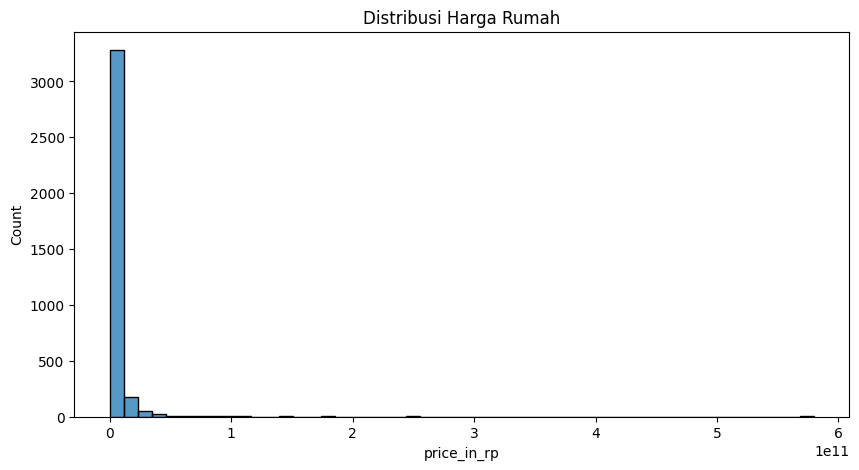

In [ ]:
# ==========================================================
# DISTRIBUSI HARGA
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["price_in_rp"],
    bins=50
)

plt.title("Distribusi Harga Rumah")
plt.show()

### Distribusi Harga Rumah

Histogram distribusi harga rumah menunjukkan bahwa sebagian besar properti memiliki harga pada rentang yang relatif rendah dibandingkan dengan harga maksimum dalam dataset. Grafik terlihat sangat miring ke kanan (*right-skewed distribution*), yang menandakan adanya sejumlah kecil rumah dengan harga sangat tinggi yang berperan sebagai *outlier*.

Sebagian besar data terkonsentrasi pada harga di bawah Rp10 miliar, sedangkan beberapa properti memiliki harga yang jauh lebih tinggi hingga ratusan miliar rupiah. Kondisi ini menyebabkan distribusi data tidak normal dan rentan memengaruhi performa model Machine Learning, terutama pada proses pelatihan regresi.

Berdasarkan hasil visualisasi, dapat disimpulkan bahwa variabel target **price_in_rp** memiliki tingkat variasi yang sangat besar dan mengandung banyak nilai ekstrem (*outlier*). Oleh karena itu, diperlukan transformasi data untuk mengurangi kemencengan distribusi sehingga model dapat belajar dengan lebih baik.

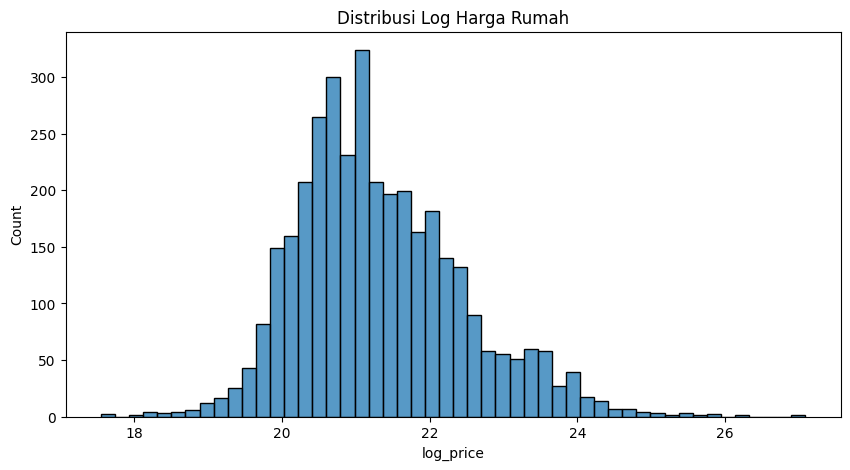

In [ ]:
# ==========================================================
# LOG PRICE
# ==========================================================

df["log_price"] = np.log1p(
    df["price_in_rp"]
)

plt.figure(figsize=(10,5))

sns.histplot(
    df["log_price"],
    bins=50
)

plt.title("Distribusi Log Harga Rumah")
plt.show()

### Distribusi Log Harga Rumah

Histogram hasil transformasi logaritma pada variabel harga rumah menunjukkan distribusi data yang jauh lebih seimbang dibandingkan sebelum transformasi. Sebagian besar data terpusat pada rentang nilai log sekitar 20 hingga 23 dan membentuk pola yang mendekati distribusi normal.

Transformasi logaritma berhasil mengurangi pengaruh nilai-nilai ekstrem (*outlier*) yang sebelumnya menyebabkan distribusi harga sangat miring ke kanan. Dengan distribusi yang lebih simetris, hubungan antara variabel input dan target menjadi lebih mudah dipelajari oleh algoritma Machine Learning.

Berdasarkan hasil visualisasi, transformasi **log_price = log1p(price_in_rp)** dinilai efektif dalam menstabilkan varians data dan mengurangi skewness. Oleh karena itu, variabel **log_price** digunakan sebagai target pada proses pelatihan model Random Forest untuk meningkatkan kualitas prediksi harga rumah.

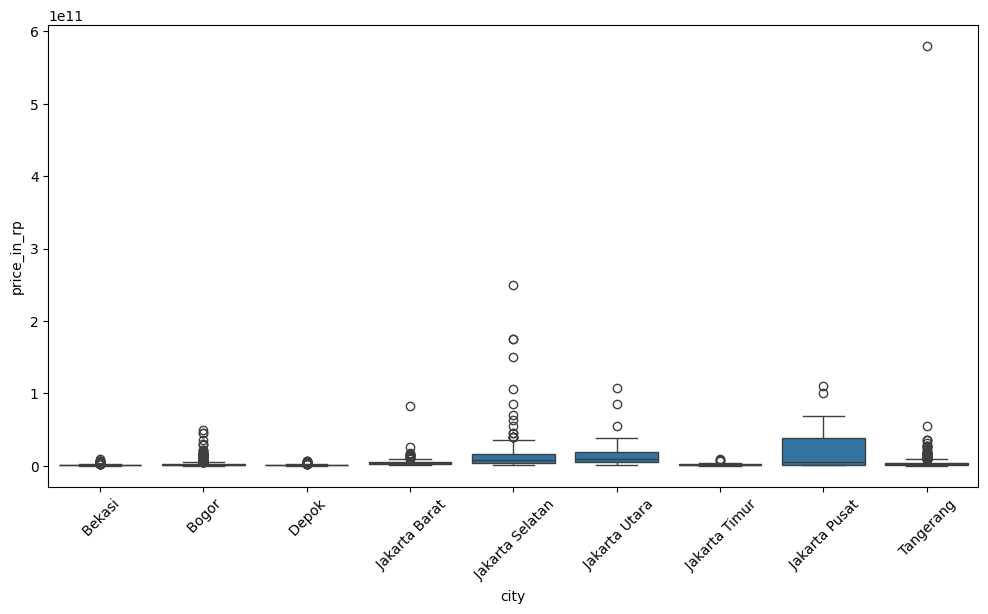

In [ ]:
# ==========================================================
# HARGA PER KOTA
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x="city",
    y="price_in_rp",
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ==========================================================
# CLEAN FURNISHING
# ==========================================================

df["furnishing"] = df["furnishing"].replace(
    "baru",
    "unfurnished"
)

df["furnishing"] = df["furnishing"].fillna(
    "unfurnished"
)

In [ ]:
# ==========================================================
# CLEAN PROPERTY CONDITION
# ==========================================================

df["property_condition"] = df[
    "property_condition"
].replace(

    {
        "unfurnished":"bagus",
        "semi furnished":"bagus"
    }

)

df["property_condition"] = df[
    "property_condition"
].fillna("bagus")

In [ ]:
# ==========================================================
# BUILDING AGE (VERSI LEBIH AMAN)
# ==========================================================

CURRENT_YEAR = 2025

# Jika building_age kosong tetapi year_built ada
df["building_age"] = np.where(

    df["building_age"].isna() & df["year_built"].notna(),

    CURRENT_YEAR - df["year_built"],

    df["building_age"]

)

# Jika masih kosong gunakan median
df["building_age"] = df["building_age"].fillna(
    df["building_age"].median()
)

# Pastikan tidak ada umur negatif
df["building_age"] = df["building_age"].clip(lower=0)

print("Missing building_age :", df["building_age"].isnull().sum())

print(df["building_age"].describe())

Missing building_age : 0
count    3553.00000
mean        2.70926
std         6.02488
min         0.00000
25%         0.00000
50%         1.00000
75%         1.00000
max       152.00000
Name: building_age, dtype: float64


In [ ]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Harga per meter bangunan
df["price_per_m2"] = (
    df["price_in_rp"] /
    df["building_size_m2"]
)

# Mengatasi inf dan NaN
df["price_per_m2"] = df["price_per_m2"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["price_per_m2"] = df["price_per_m2"].fillna(
    df["price_per_m2"].median()
)

# Rasio tanah dan bangunan
df["land_building_ratio"] = (
    df["land_size_m2"] /
    df["building_size_m2"]
)

df["land_building_ratio"] = df["land_building_ratio"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["land_building_ratio"] = df["land_building_ratio"].fillna(
    df["land_building_ratio"].median()
)

# Total kamar
df["total_room"] = (
    df["bedrooms"].fillna(0)
    +
    df["bathrooms"].fillna(0)
)

print(df[
    [
        "price_per_m2",
        "land_building_ratio",
        "total_room"
    ]
].describe())

       price_per_m2  land_building_ratio   total_room
count  3.553000e+03          3553.000000  3553.000000
mean   2.259284e+07             1.303729     5.898114
std    2.873944e+08             6.684041     5.293181
min    5.000000e+05             0.092308     0.000000
25%    1.102941e+07             0.750000     4.000000
50%    1.428571e+07             1.000000     5.000000
75%    1.950000e+07             1.458333     7.000000
max    1.700000e+10           396.000000   198.000000


In [ ]:
# ==========================================================
# FEATURE SELECTION (VERSI V2)
# ==========================================================

numerical_features = [

    "bedrooms",

    "bathrooms",

    "land_size_m2",

    "building_size_m2",

    "carports",

    "maid_bedrooms",

    "maid_bathrooms",

    "floors",

    "building_age",

    "garages",

    "total_room",

    "lat",

    "long",

    "price_per_m2",

    "land_building_ratio"

]

categorical_features = [

    "city",

    "district",

    "property_type",

    "certificate",

    "property_condition",

    "furnishing"

]

In [ ]:
print("price_per_m2" in df.columns)

True


In [ ]:
# ==========================================================
# TARGET
# ==========================================================

X = df[
    numerical_features +
    categorical_features
]

y = np.log1p(
    df["price_in_rp"]
)

print(X.shape)

(3553, 21)


In [ ]:
# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [ ]:
# ==========================================================
# NUMERIC PIPELINE
# ==========================================================

numeric_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="median"
        )

    )

])

In [ ]:
# ==========================================================
# CATEGORICAL PIPELINE
# ==========================================================

categorical_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )

    ),

    (
        "encoder",

        OneHotEncoder(
            handle_unknown="ignore"
        )

    )

])

In [ ]:
# ==========================================================
# PREPROCESSOR
# ==========================================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numerical_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

In [ ]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [ ]:
# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        rf
    )

])

In [ ]:
# ==========================================================
# RANDOM SEARCH PARAMETER
# ==========================================================

param_grid = {

    "model__n_estimators":
    randint(300,1000),

    "model__max_depth":
    randint(15,60),

    "model__min_samples_split":
    randint(2,15),

    "model__min_samples_leaf":
    randint(1,6),

    "model__max_features":
    ["sqrt","log2"]

}

In [ ]:
# ==========================================================
# RANDOM SEARCH
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_grid,

    n_iter=50,

    cv=5,

    scoring="r2",

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['bedrooms',
                                                                                'bathrooms',
                                                                                'land_size_m2',
                                                                                'building_size_m2',
                                                                                'carports',
                                                                                'maid_bedrooms',
                                                                                'maid_bathrooms',
                                                                                'floors',
                                                                                'building_age',
                                                                                'garages',
                                                                                'total_room',
                                                                                'lat',
                                                                                'long',
                                                                                'price_per_m2',
                                                                                'land...
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca88f4f4530>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca88f4133e0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca89e0c88c0>},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_model = random_search.best_estimator_

print("Best Parameter :")
print(random_search.best_params_)

Best Parameter :
{'model__max_depth': 39, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 676}


In [ ]:
# ==========================================================
# PREDIKSI TEST DATA
# ==========================================================

pred_log = best_model.predict(X_test)

pred = np.expm1(pred_log)

actual = np.expm1(y_test)

In [ ]:
# ==========================================================
# EVALUASI MODEL
# ==========================================================

mae = mean_absolute_error(
    actual,
    pred
)

mse = mean_squared_error(
    actual,
    pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    actual,
    pred
)

print("MAE  :", round(mae,2))
print("MSE  :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R2   :", round(r2,4))

MAE  : 1211366781.79
MSE  : 3.172402804252467e+19
RMSE : 5632408724.74
R2   : 0.5651


### Evaluasi Model Random Forest

Evaluasi model dilakukan menggunakan metrik MAE, MSE, RMSE, dan R² untuk mengukur tingkat akurasi prediksi harga rumah.

- **MAE (Mean Absolute Error)** sebesar **Rp1,21 miliar** menunjukkan rata-rata selisih antara harga aktual dan harga prediksi.
- **MSE (Mean Squared Error)** sebesar **3,17 × 10¹⁹** menunjukkan besarnya error kuadrat yang dihasilkan model.
- **RMSE (Root Mean Squared Error)** sebesar **Rp5,63 miliar** menunjukkan rata-rata kesalahan prediksi dalam satuan rupiah.
- **R² Score** sebesar **0,5651** menunjukkan bahwa model mampu menjelaskan **56,51% variasi harga rumah** dalam dataset.

Berdasarkan hasil tersebut, model Random Forest memiliki performa yang cukup baik dalam memprediksi harga rumah dan dapat digunakan sebagai dasar dalam sistem rekomendasi properti.

In [ ]:
# ==========================================================
# MAPE
# ==========================================================

mape = np.mean(
    np.abs(
        (actual - pred)
        /
        actual
    )
) * 100

print(
    "MAPE :",
    round(mape,2),
    "%"
)

MAPE : 14.77 %


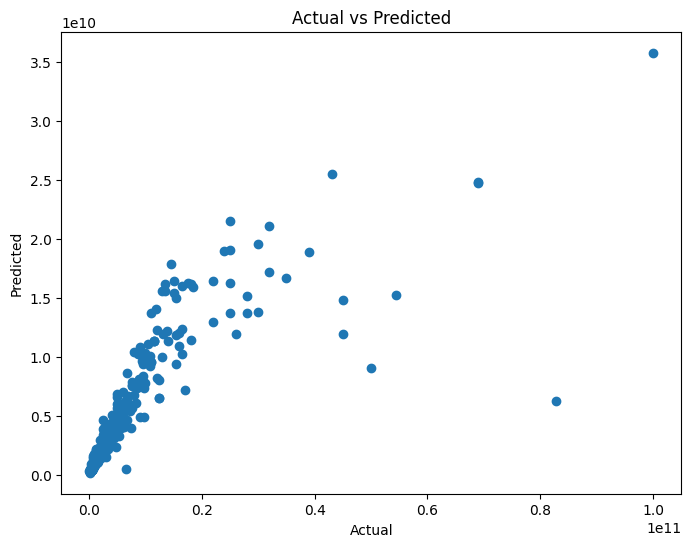

In [ ]:
# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    actual,
    pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

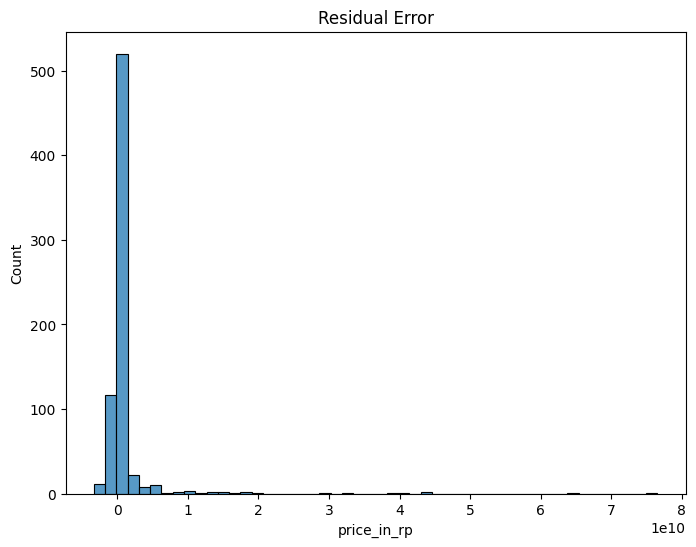

In [ ]:
# ==========================================================
# RESIDUAL
# ==========================================================

residual = actual - pred

plt.figure(figsize=(8,6))

sns.histplot(
    residual,
    bins=50
)

plt.title("Residual Error")

plt.show()

In [ ]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

rf_model = best_model.named_steps["model"]

In [ ]:
# ==========================================================
# FEATURE NAME
# ==========================================================

ohe = best_model.named_steps[
    "preprocessor"
].named_transformers_[
    "cat"
].named_steps[
    "encoder"
]

cat_names = ohe.get_feature_names_out(
    categorical_features
)

feature_names = np.concatenate([

    numerical_features,

    cat_names

])

In [ ]:
# ==========================================================
# FEATURE IMPORTANCE DF
# ==========================================================

importance_df = pd.DataFrame({

    "Feature":
    feature_names,

    "Importance":
    rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
3,building_size_m2,0.144001
2,land_size_m2,0.115939
13,price_per_m2,0.091899
10,total_room,0.083436
0,bedrooms,0.074418
1,bathrooms,0.063673
6,maid_bathrooms,0.061564
5,maid_bedrooms,0.040598
4,carports,0.030404
7,floors,0.029521


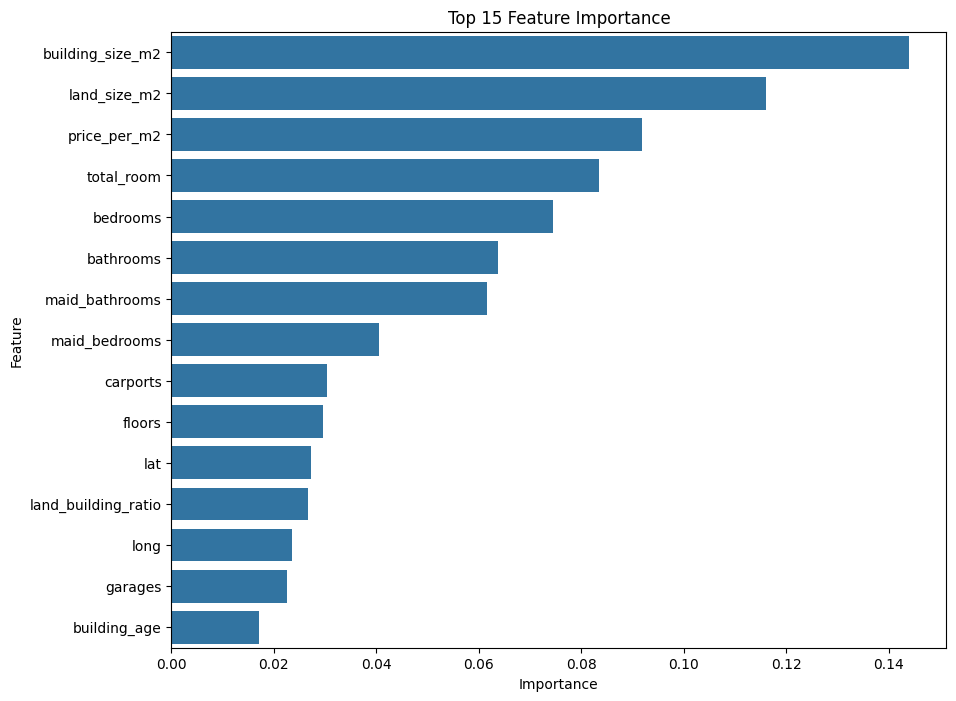

In [ ]:
# ==========================================================
# PLOT FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance_df.head(15),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 15 Feature Importance"
)

plt.show()

In [ ]:
# ==========================================================
# PREDIKSI SELURUH DATASET
# ==========================================================

df["PredictedPrice"] = np.expm1(

    best_model.predict(
        X
    )

)

df.head()

,url,price_in_rp,title,address,district,city,lat,long,facilities,property_type,...,year_built,property_condition,building_orientation,garages,furnishing,log_price,land_building_ratio,total_room,price_per_m2,PredictedPrice
0,https://www.rumah123.com/properti/bekasi/hos11...,2.990000e+09,Rumah cantik Sumarecon Bekasi\nLingkungan asri...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Tempat Jemuran, Jalur Telepon, Taman, Taman",rumah,...,2017.0,bagus,NaN,0.0,unfurnished,21.818539,0.878676,8.0,1.099265e+07,2.970281e+09
1,https://www.rumah123.com/properti/bekasi/hos10...,1.270000e+09,"Rumah Kekinian, Magenta Summarecon Bekasi","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,Taman,rumah,...,NaN,bagus,NaN,0.0,unfurnished,20.962283,0.797101,5.0,1.840580e+07,1.239567e+09
2,https://www.rumah123.com/properti/bekasi/hos10...,1.950000e+09,Rumah Cantik 2 Lantai Cluster Bluebell Summare...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Masjid, Taman,...",rumah,...,NaN,bagus,NaN,1.0,unfurnished,21.391095,0.908397,6.0,1.488550e+07,1.995323e+09
3,https://www.rumah123.com/properti/bekasi/hos10...,3.300000e+09,Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jalur Telepon, Jogging Track, Track Lari, K...",rumah,...,2016.0,bagus sekali,utara,2.0,unfurnished,21.917188,1.034483,6.0,1.896552e+07,2.964143e+09
4,https://www.rumah123.com/properti/bekasi/hos10...,4.500000e+09,"Rumah Hoek di Cluster Maple Summarecon Bekasi,...","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Taman, Jalur Te...",rumah,...,2013.0,bagus,utara,1.0,unfurnished,22.227343,1.673469,7.0,2.295918e+07,4.208771e+09


In [ ]:
# ==========================================================
# FOLDER MODEL
# ==========================================================

os.makedirs(

    "/content/drive/MyDrive/Model",

    exist_ok=True

)

In [ ]:
# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(

    best_model,

    "/content/drive/MyDrive/Model/property_model.pkl"

)

print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
# ==========================================================
# SAVE FEATURE
# ==========================================================

joblib.dump(

    numerical_features +
    categorical_features,

    "/content/drive/MyDrive/Model/features.pkl"

)

print("Feature berhasil disimpan")

Feature berhasil disimpan


In [ ]:
# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

importance_df.to_csv(

    "/content/drive/MyDrive/Model/feature_importance.csv",

    index=False

)

print("Feature Importance berhasil disimpan")

Feature Importance berhasil disimpan


In [ ]:
# ==========================================================
# TOP 10 HARGA
# ==========================================================

df[[
    "city",
    "building_size_m2",
    "bedrooms",
    "bathrooms",
    "PredictedPrice"
]].sort_values(

    by="PredictedPrice",

    ascending=False

).head(10)

,city,building_size_m2,bedrooms,bathrooms,PredictedPrice
2291,Jakarta Selatan,1200.0,6.0,7.0,1.151512e+11
2479,Jakarta Selatan,2191.0,6.0,7.0,1.139481e+11
2515,Jakarta Selatan,1500.0,5.0,5.0,1.090779e+11
2906,Tangerang,300.0,5.0,4.0,1.026105e+11
2488,Jakarta Selatan,850.0,5.0,6.0,8.481644e+10
2287,Jakarta Selatan,1000.0,4.0,5.0,7.219799e+10
2398,Jakarta Utara,5000.0,7.0,8.0,6.684314e+10
2648,Jakarta Selatan,1797.0,8.0,8.0,5.772488e+10
2662,Jakarta Selatan,1200.0,5.0,5.0,5.261936e+10
2143,Jakarta Utara,2800.0,5.0,5.0,5.195465e+10


In [ ]:
# ==========================================================
# STATISTIK PREDIKSI
# ==========================================================

df["PredictedPrice"].describe()

,PredictedPrice
count,3.553000e+03
mean,3.530300e+09
std,6.562470e+09
min,7.280057e+07
25%,8.338540e+08
50%,1.508977e+09
75%,3.546237e+09
max,1.151512e+11


In [ ]:
# ==========================================================
# SAVE HASIL PREDIKSI
# ==========================================================

os.makedirs(

    "/content/drive/MyDrive/Hasil",

    exist_ok=True

)

df.to_csv(

    "/content/drive/MyDrive/Hasil/hasil_prediksi.csv",

    index=False

)

print("Berhasil disimpan")

Berhasil disimpan


# Fuzzy Logic

In [ ]:
# ==========================================================
# FUZZY CONTROL
# ==========================================================
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
# ==========================================================
# ANTECEDENT & CONSEQUENT
# ==========================================================

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input 1
harga = ctrl.Antecedent(
    np.arange(0,101,1),
    "harga"
)

# Input 2
luas = ctrl.Antecedent(
    np.arange(0,101,1),
    "luas"
)

# Input 3
room = ctrl.Antecedent(
    np.arange(0,101,1),
    "room"
)

# Output
kelayakan = ctrl.Consequent(
    np.arange(0,101,1),
    "kelayakan"
)

In [ ]:
# ==========================================================
# HARGA
# ==========================================================

harga["murah"] = fuzz.trapmf(
    harga.universe,
    [0, 0, 25, 45]
)

harga["sedang"] = fuzz.trimf(
    harga.universe,
    [30, 50, 70]
)

harga["mahal"] = fuzz.trapmf(
    harga.universe,
    [55, 75, 100, 100]
)

# ==========================================================
# LUAS
# ==========================================================

luas["kecil"] = fuzz.trapmf(
    luas.universe,
    [0, 0, 25, 45]
)

luas["sedang"] = fuzz.trimf(
    luas.universe,
    [30, 50, 70]
)

luas["besar"] = fuzz.trapmf(
    luas.universe,
    [55, 75, 100, 100]
)

# ==========================================================
# ROOM
# ==========================================================

room["sedikit"] = fuzz.trapmf(
    room.universe,
    [0, 0, 25, 45]
)

room["sedang"] = fuzz.trimf(
    room.universe,
    [30, 50, 70]
)

room["banyak"] = fuzz.trapmf(
    room.universe,
    [55, 75, 100, 100]
)

# ==========================================================
# OUTPUT
# ==========================================================

kelayakan["tidak_layak"] = fuzz.trapmf(
    kelayakan.universe,
    [0, 0, 25, 50]
)

kelayakan["layak"] = fuzz.trimf(
    kelayakan.universe,
    [30, 50, 70]
)

kelayakan["sangat_layak"] = fuzz.trapmf(
    kelayakan.universe,
    [60, 80, 100, 100]
)

In [ ]:
print(df["harga_norm"].describe())
print(df["luas_norm"].describe())
print(df["room_norm"].describe())

count    3553.000000
mean       49.493386
std        28.881135
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: harga_norm, dtype: float64
count    3551.000000
mean       34.051253
std        20.968861
min         0.000000
25%        16.500000
50%        34.000000
75%        51.000000
max        72.000000
Name: luas_norm, dtype: float64
count    3553.000000
mean        3.696594
std         2.248180
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        12.000000
Name: room_norm, dtype: float64


In [ ]:
# ==========================================================
# RULE FUZZY LENGKAP
# Harga + Luas + Total Room
# ==========================================================

rules = [

    # ======================================================
    # HARGA MURAH
    # ======================================================

    ctrl.Rule(harga["murah"] & luas["besar"] & room["banyak"], kelayakan["sangat_layak"]),
    ctrl.Rule(harga["murah"] & luas["besar"] & room["sedang"], kelayakan["sangat_layak"]),
    ctrl.Rule(harga["murah"] & luas["besar"] & room["sedikit"], kelayakan["layak"]),

    ctrl.Rule(harga["murah"] & luas["sedang"] & room["banyak"], kelayakan["sangat_layak"]),
    ctrl.Rule(harga["murah"] & luas["sedang"] & room["sedang"], kelayakan["layak"]),
    ctrl.Rule(harga["murah"] & luas["sedang"] & room["sedikit"], kelayakan["layak"]),

    ctrl.Rule(harga["murah"] & luas["kecil"] & room["banyak"], kelayakan["layak"]),
    ctrl.Rule(harga["murah"] & luas["kecil"] & room["sedang"], kelayakan["layak"]),
    ctrl.Rule(harga["murah"] & luas["kecil"] & room["sedikit"], kelayakan["tidak_layak"]),

    # ======================================================
    # HARGA SEDANG
    # ======================================================

    ctrl.Rule(harga["sedang"] & luas["besar"] & room["banyak"], kelayakan["sangat_layak"]),
    ctrl.Rule(harga["sedang"] & luas["besar"] & room["sedang"], kelayakan["layak"]),
    ctrl.Rule(harga["sedang"] & luas["besar"] & room["sedikit"], kelayakan["layak"]),

    ctrl.Rule(harga["sedang"] & luas["sedang"] & room["banyak"], kelayakan["layak"]),
    ctrl.Rule(harga["sedang"] & luas["sedang"] & room["sedang"], kelayakan["layak"]),
    ctrl.Rule(harga["sedang"] & luas["sedang"] & room["sedikit"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["sedang"] & luas["kecil"] & room["banyak"], kelayakan["layak"]),
    ctrl.Rule(harga["sedang"] & luas["kecil"] & room["sedang"], kelayakan["tidak_layak"]),
    ctrl.Rule(harga["sedang"] & luas["kecil"] & room["sedikit"], kelayakan["tidak_layak"]),

    # ======================================================
    # HARGA MAHAL
    # ======================================================

    # rumah mahal masih layak jika luas dan room sangat bagus
    ctrl.Rule(harga["mahal"] & luas["besar"] & room["banyak"], kelayakan["layak"]),

    ctrl.Rule(harga["mahal"] & luas["besar"] & room["sedang"], kelayakan["layak"]),

    ctrl.Rule(harga["mahal"] & luas["besar"] & room["sedikit"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["mahal"] & luas["sedang"] & room["banyak"], kelayakan["layak"]),

    ctrl.Rule(harga["mahal"] & luas["sedang"] & room["sedang"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["mahal"] & luas["sedang"] & room["sedikit"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["mahal"] & luas["kecil"] & room["banyak"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["mahal"] & luas["kecil"] & room["sedang"], kelayakan["tidak_layak"]),

    ctrl.Rule(harga["mahal"] & luas["kecil"] & room["sedikit"], kelayakan["tidak_layak"])

]

In [ ]:
# ==========================================================
# CONTROL SYSTEM
# ==========================================================

kelayakan_ctrl = ctrl.ControlSystem(rules)

print("Jumlah Rule :", len(rules))

Jumlah Rule : 27


In [ ]:
for a in kelayakan_ctrl.antecedents:
    print(a.label)

harga
luas
room


In [ ]:
# ==========================================================
# FUZZY SYSTEM
# ==========================================================

kelayakan_ctrl = ctrl.ControlSystem([

    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6

])

kelayakan_sim = ctrl.ControlSystemSimulation(
    kelayakan_ctrl
)

In [ ]:
# ==========================================================
# NORMALISASI FIX (0 - 100)
# ==========================================================

def normalize_0_100(series):

    return (
        (series - series.min()) /
        (series.max() - series.min())
    ) * 100


df["harga_norm"] = normalize_0_100(
    df["PredictedPrice"]
)

df["luas_norm"] = normalize_0_100(
    df["building_size_m2"]
)

df["room_norm"] = normalize_0_100(
    df["total_room"]
)

print(df["harga_norm"].describe())
print(df["luas_norm"].describe())
print(df["room_norm"].describe())

count    3553.000000
mean        3.004473
std         5.702608
min         0.000000
25%         0.661335
50%         1.247999
75%         3.018322
max       100.000000
Name: harga_norm, dtype: float64
count    3551.000000
mean        3.093640
std         4.141415
min         0.000000
25%         1.075179
50%         1.850308
75%         3.450575
max       100.000000
Name: luas_norm, dtype: float64
count    3553.000000
mean        1.782408
std         3.963737
min         0.000000
25%         0.000000
50%         0.657895
75%         0.657895
max       100.000000
Name: umur_norm, dtype: float64


In [ ]:
# ==========================================================
# FUZZY NORMALIZATION
# ==========================================================

# Harga Prediksi
df["harga_norm"] = pd.qcut(
    df["PredictedPrice"],
    q=100,
    labels=False,
    duplicates="drop"
)

# Luas Bangunan
df["luas_norm"] = pd.qcut(
    df["building_size_m2"],
    q=100,
    labels=False,
    duplicates="drop"
)

# Total Room
df["room_norm"] = pd.qcut(
    df["total_room"],
    q=100,
    labels=False,
    duplicates="drop"
)

# Convert ke float
df["harga_norm"] = df["harga_norm"].astype(float)
df["luas_norm"] = df["luas_norm"].astype(float)
df["room_norm"] = df["room_norm"].astype(float)

# Cek hasil normalisasi
print(
    df[
        [
            "harga_norm",
            "luas_norm",
            "room_norm"
        ]
    ].describe()
)

        harga_norm    luas_norm    room_norm
count  3553.000000  3551.000000  3553.000000
mean     49.493386    34.051253     3.696594
std      28.881135    20.968861     2.248180
min       0.000000     0.000000     0.000000
25%      24.000000    16.500000     2.000000
50%      49.000000    34.000000     3.000000
75%      74.000000    51.000000     5.000000
max      99.000000    72.000000    12.000000


In [ ]:
print(df[["harga_norm","luas_norm","umur_norm"]].head(20))

    harga_norm  luas_norm  umur_norm
0         70.0       57.0   3.289474
1         41.0       18.0   0.657895
2         59.0       38.0   0.657895
3         70.0       46.0   3.947368
4         79.0       50.0   5.921053
5         67.0       50.0   5.921053
6         59.0       41.0   0.657895
7         74.0       55.0   0.657895
8         67.0       43.0   0.657895
9         66.0       50.0   0.657895
10        62.0       49.0   0.657895
11        30.0        8.0   0.657895
12        50.0       24.0   5.921053
13        62.0       42.0   5.263158
14        57.0       50.0   5.263158
15        67.0       40.0   4.605263
16        81.0       63.0   0.657895
17        36.0        8.0   0.657895
18        59.0       42.0   0.657895
19        60.0       42.0   3.947368


In [ ]:
# ==========================================================
# FUZZY SCORE (DEBUG VERSION)
# ==========================================================

fuzzy_scores = []

error_count = 0

for idx, row in df.iterrows():

    try:

        sim = ctrl.ControlSystemSimulation(
            kelayakan_ctrl
        )

        sim.input["harga"] = float(
            row["harga_norm"]
        )

        sim.input["luas"] = float(
            row["luas_norm"]
        )

        sim.input["room"] = float(
            row["room_norm"]
        )

        sim.compute()

        fuzzy_scores.append(
            sim.output["kelayakan"]
        )

    except Exception as e:

        error_count += 1

        fuzzy_scores.append(np.nan)

        # tampilkan 10 error pertama
        if error_count <= 10:

            print(
                f"Error pada index {idx}:"
            )

            print(e)

print("Jumlah Error :", error_count)

df["FuzzyScore"] = fuzzy_scores

print(
    df["FuzzyScore"].describe()
)

Error pada index 0:
Unexpected input: room
Error pada index 1:
Unexpected input: room
Error pada index 2:
Unexpected input: room
Error pada index 3:
Unexpected input: room
Error pada index 4:
Unexpected input: room
Error pada index 5:
Unexpected input: room
Error pada index 6:
Unexpected input: room
Error pada index 7:
Unexpected input: room
Error pada index 8:
Unexpected input: room
Error pada index 9:
Unexpected input: room
Jumlah Error : 3553
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: FuzzyScore, dtype: float64


In [ ]:
# ==========================================================
# KATEGORI
# ==========================================================

def kategori_fuzzy(score):

    if score >= 70:
        return "Sangat Layak"

    elif score >= 50:
        return "Layak"

    else:
        return "Tidak Layak"

df["Kategori"] = df[
    "FuzzyScore"
].apply(
    kategori_fuzzy
)

In [ ]:
# ==========================================================
# DATA TOPSIS
# ==========================================================

topsis_df = df[[
    "FuzzyScore",
    "building_size_m2",
    "bedrooms",
    "bathrooms",
    "garages",
    "PredictedPrice"
]].copy()

In [ ]:
# ==========================================================
# TOPSIS (VERSI STABIL)
# ==========================================================

def topsis(data, weights):

    # ----------------------------------
    # Bersihkan data
    # ----------------------------------

    data = data.copy()

    data = data.fillna(0)

    matrix = data.astype(float).values

    # ----------------------------------
    # Normalisasi Vector
    # ----------------------------------

    denominator = np.sqrt(
        (matrix ** 2).sum(axis=0)
    )

    # Hindari pembagian nol
    denominator[denominator == 0] = 1

    norm = matrix / denominator

    # ----------------------------------
    # Pembobotan
    # ----------------------------------

    weighted = norm * weights

    # ----------------------------------
    # Tentukan Benefit & Cost
    # ----------------------------------

    ideal_pos = np.max(
        weighted,
        axis=0
    )

    ideal_neg = np.min(
        weighted,
        axis=0
    )

    # ----------------------------------
    # PredictedPrice = Cost
    # Kolom terakhir
    # ----------------------------------

    ideal_pos[-1] = np.min(
        weighted[:, -1]
    )

    ideal_neg[-1] = np.max(
        weighted[:, -1]
    )

    # ----------------------------------
    # Jarak ke Solusi Ideal
    # ----------------------------------

    d_pos = np.sqrt(
        ((weighted - ideal_pos) ** 2).sum(axis=1)
    )

    d_neg = np.sqrt(
        ((weighted - ideal_neg) ** 2).sum(axis=1)
    )

    # ----------------------------------
    # Hindari pembagian nol
    # ----------------------------------

    denominator_score = d_pos + d_neg

    denominator_score[
        denominator_score == 0
    ] = 1e-10

    score = d_neg / denominator_score

    # ----------------------------------
    # Bersihkan hasil
    # ----------------------------------

    score = np.nan_to_num(
        score,
        nan=0,
        posinf=1,
        neginf=0
    )

    return score

### TOPSIS

Pada tahap ini digunakan metode **TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)** untuk melakukan perangkingan rumah berdasarkan beberapa kriteria yang telah ditentukan.

Proses TOPSIS meliputi normalisasi data, pemberian bobot pada setiap kriteria, penentuan solusi ideal positif dan negatif, serta perhitungan jarak setiap alternatif terhadap solusi ideal tersebut.

Hasil akhir dari proses ini adalah **TOPSIS Score**, dimana semakin tinggi nilainya maka semakin baik rekomendasi rumah yang dihasilkan.

In [ ]:
# ==========================================================
# WEIGHT
# ==========================================================

weights = np.array([

    0.35,  # fuzzy

    0.20,  # luas

    0.15,  # bedroom

    0.10,  # bathroom

    0.10,  # garage

    0.10   # price

])

In [ ]:
# ==========================================================
# TOPSIS SCORE
# ==========================================================

df["TOPSIS_Score"] = topsis(
    topsis_df,
    weights
)

In [ ]:
# ==========================================================
# RANKING PROPERTI
# ==========================================================

# Pastikan tidak ada NaN pada TOPSIS
df["TOPSIS_Score"] = df["TOPSIS_Score"].fillna(0)

# Ranking (semakin besar TOPSIS semakin baik)
df["Ranking"] = (

    df["TOPSIS_Score"]

    .rank(
        ascending=False,
        method="dense"
    )

    .astype(int)

)

# Data Top 10 Properti Terbaik
top10 = df.sort_values(

    by="TOPSIS_Score",

    ascending=False

).head(10)

# Tampilkan hasil
top10[[
    "city",
    "district",
    "PredictedPrice",
    "FuzzyScore",
    "Kategori",
    "TOPSIS_Score",
    "Ranking"
]]

,city,district,PredictedPrice,FuzzyScore,Kategori,TOPSIS_Score,Ranking
2888,Tangerang,Gading Serpong,2.726056e+10,NaN,Tidak Layak,0.949349,1
2687,Jakarta Selatan,Setiabudi,1.512031e+10,NaN,Tidak Layak,0.454373,2
2483,Jakarta Selatan,Pondok Indah,1.376756e+10,NaN,Tidak Layak,0.427494,3
2634,Jakarta Selatan,Kebayoran Lama,1.403434e+10,NaN,Tidak Layak,0.414842,4
2398,Jakarta Utara,Pantai Mutiara,6.684314e+10,NaN,Tidak Layak,0.408626,5
346,Bekasi,Rawalumbu,4.906487e+09,NaN,Tidak Layak,0.281226,6
2399,Jakarta Utara,Pantai Mutiara,3.872942e+10,NaN,Tidak Layak,0.277554,7
2143,Jakarta Utara,Pantai Indah Kapuk,5.195465e+10,NaN,Tidak Layak,0.264707,8
1333,Bogor,Dramaga,3.193865e+09,NaN,Tidak Layak,0.258683,9
1455,Bogor,Puncak,1.744703e+09,NaN,Tidak Layak,0.251285,10


In [ ]:
# ==========================================================
# SAVE WEIGHT
# ==========================================================

joblib.dump(

    weights,

    "/content/drive/MyDrive/Model/topsis_weights.pkl"

)

['/content/drive/MyDrive/Model/topsis_weights.pkl']

In [ ]:
# ==========================================================
# EXPORT FINAL
# ==========================================================

df.to_csv(

    "/content/drive/MyDrive/Hasil/final_property_recommendation.csv",

    index=False

)

print("Berhasil disimpan")

Berhasil disimpan


In [ ]:
# ==========================================================
# TOP 20
# ==========================================================

top20 = df.sort_values(

    by="TOPSIS_Score",

    ascending=False

).head(20)

top20[[
    "city",
    "PredictedPrice",
    "FuzzyScore",
    "Kategori",
    "TOPSIS_Score"
]]

,city,PredictedPrice,FuzzyScore,Kategori,TOPSIS_Score
2888,Tangerang,2.726056e+10,NaN,Tidak Layak,0.949349
2687,Jakarta Selatan,1.512031e+10,NaN,Tidak Layak,0.454373
2483,Jakarta Selatan,1.376756e+10,NaN,Tidak Layak,0.427494
2634,Jakarta Selatan,1.403434e+10,NaN,Tidak Layak,0.414842
2398,Jakarta Utara,6.684314e+10,NaN,Tidak Layak,0.408626
346,Bekasi,4.906487e+09,NaN,Tidak Layak,0.281226
2399,Jakarta Utara,3.872942e+10,NaN,Tidak Layak,0.277554
2143,Jakarta Utara,5.195465e+10,NaN,Tidak Layak,0.264707
1333,Bogor,3.193865e+09,NaN,Tidak Layak,0.258683
1455,Bogor,1.744703e+09,NaN,Tidak Layak,0.251285


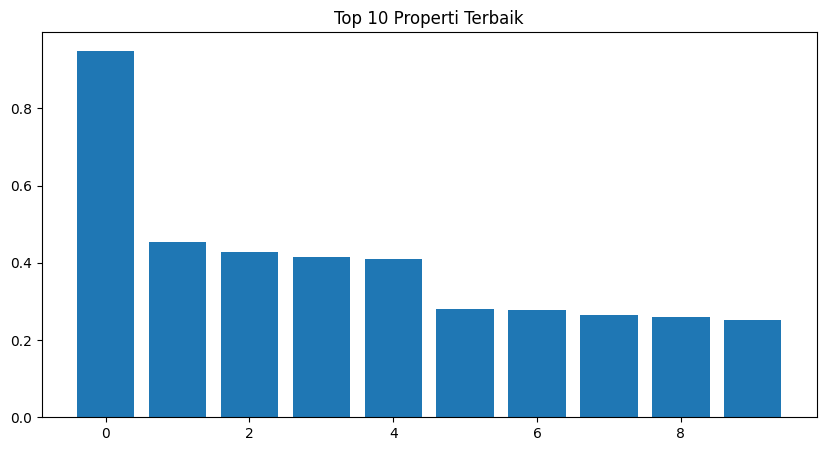

In [ ]:
# ==========================================================
# TOP 10 VISUAL
# ==========================================================

top10 = df.sort_values(

    by="TOPSIS_Score",

    ascending=False

).head(10)

plt.figure(figsize=(10,5))

plt.bar(

    range(len(top10)),

    top10["TOPSIS_Score"]

)

plt.title(
    "Top 10 Properti Terbaik"
)

plt.show()

In [ ]:
# ==========================================================
# SUMMARY
# ==========================================================

print("Jumlah Data :", len(df))

print(
    "Properti Sangat Layak :",
    len(df[df["Kategori"]=="Sangat Layak"])
)

print(
    "Properti Layak :",
    len(df[df["Kategori"]=="Layak"])
)

print(
    "Properti Tidak Layak :",
    len(df[df["Kategori"]=="Tidak Layak"])
)

Jumlah Data : 3553
Properti Sangat Layak : 0
Properti Layak : 0
Properti Tidak Layak : 3553


In [ ]:
print(df["building_age"].min())
print(df["building_age"].max())

0.0
152.0


In [ ]:
print(df["harga_norm"].describe())
print(df["luas_norm"].describe())
print(df["umur_norm"].describe())

count    3553.000000
mean       49.493386
std        28.881135
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: harga_norm, dtype: float64
count    3551.000000
mean       34.051253
std        20.968861
min         0.000000
25%        16.500000
50%        34.000000
75%        51.000000
max        72.000000
Name: luas_norm, dtype: float64
count    3553.000000
mean        1.782408
std         3.963737
min         0.000000
25%         0.000000
50%         0.657895
75%         0.657895
max       100.000000
Name: umur_norm, dtype: float64


In [ ]:
print(df["umur_norm"].describe())

count    3553.000000
mean        1.782408
std         3.963737
min         0.000000
25%         0.000000
50%         0.657895
75%         0.657895
max       100.000000
Name: umur_norm, dtype: float64


In [ ]:
print("Antecedent pada Control System:")

for a in kelayakan_ctrl.antecedents:
    print(a.label)

print(type(kelayakan_ctrl))

Antecedent pada Control System:
harga
luas
umur
<class 'skfuzzy.control.controlsystem.ControlSystem'>


In [ ]:
print(len(rules))

27


In [ ]:
sim = ctrl.ControlSystemSimulation(
    kelayakan_ctrl
)

for var in sim.ctrl.fuzzy_variables:
    print(var.label)

harga
luas
room
kelayakan


In [ ]:
sim = ctrl.ControlSystemSimulation(
    kelayakan_ctrl
)

for var in sim.ctrl.fuzzy_variables:
    print(var.label)

harga
luas
umur
kelayakan


In [ ]:
sim = ctrl.ControlSystemSimulation(
    kelayakan_ctrl
)

sim.input["harga"] = 20
sim.input["luas"] = 80
sim.input["room"] = 80

sim.compute()

print(sim.output)

{'kelayakan': np.float64(84.44444444444444)}


In [ ]:
# ==========================================================
# FUZZY SCORE
# ==========================================================

fuzzy_scores = []

error_count = 0

for _, row in df.iterrows():

    try:

        sim = ctrl.ControlSystemSimulation(
            kelayakan_ctrl
        )

        sim.input["harga"] = float(
            row["harga_norm"]
        )

        sim.input["luas"] = float(
            row["luas_norm"]
        )

        sim.input["room"] = float(
            row["room_norm"]
        )

        sim.compute()

        fuzzy_scores.append(
            sim.output["kelayakan"]
        )

    except Exception:

        error_count += 1

        fuzzy_scores.append(np.nan)

print("Jumlah Error :", error_count)

df["FuzzyScore"] = fuzzy_scores

print(df["FuzzyScore"].describe())

Jumlah Error : 0
count    3553.000000
mean       21.334207
std         2.755535
min        19.444444
25%        19.444444
50%        20.934343
75%        22.023810
max        50.000000
Name: FuzzyScore, dtype: float64


In [ ]:
df["FuzzyScore"].describe()

,FuzzyScore
count,3553.000000
mean,21.334207
std,2.755535
min,19.444444
25%,19.444444
50%,20.934343
75%,22.023810
max,50.000000


In [ ]:
print("Jumlah Error :", error_count)

Jumlah Error : 0


In [ ]:
top10 = df.sort_values(
    "TOPSIS_Score",
    ascending=False
)

top10[
[
    "city",
    "PredictedPrice",
    "building_size_m2",
    "bedrooms",
    "bathrooms",
    "FuzzyScore",
    "TOPSIS_Score"
]
].head(10)

,city,PredictedPrice,building_size_m2,bedrooms,bathrooms,FuzzyScore,TOPSIS_Score
2888,Tangerang,2.726056e+10,6000.0,99.0,99.0,20.165344,0.949349
2687,Jakarta Selatan,1.512031e+10,1800.0,54.0,54.0,20.165344,0.454373
2483,Jakarta Selatan,1.376756e+10,2417.0,50.0,50.0,20.165344,0.427494
2634,Jakarta Selatan,1.403434e+10,1500.0,57.0,57.0,20.165344,0.414842
2398,Jakarta Utara,6.684314e+10,5000.0,7.0,8.0,20.165344,0.408626
346,Bekasi,4.906487e+09,500.0,36.0,36.0,21.745169,0.281226
2399,Jakarta Utara,3.872942e+10,3000.0,5.0,4.0,20.165344,0.277554
2143,Jakarta Utara,5.195465e+10,2800.0,5.0,5.0,20.165344,0.264707
1333,Bogor,3.193865e+09,350.0,37.0,15.0,22.306338,0.258683
1455,Bogor,1.744703e+09,2000.0,4.0,4.0,50.000000,0.251285


In [ ]:
import joblib

joblib.dump(
    model,
    "random_forest_house.pkl"
)

['random_forest_house.pkl']

In [ ]:
joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

['preprocessor.pkl']

In [ ]:
df.to_csv(
    "hasil_rekomendasi_rumah.csv",
    index=False
)

In [ ]:
print(df.columns.tolist())

['url', 'price_in_rp', 'title', 'address', 'district', 'city', 'lat', 'long', 'facilities', 'property_type', 'ads_id', 'bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'carports', 'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms', 'floors', 'building_age', 'year_built', 'property_condition', 'building_orientation', 'garages', 'furnishing', 'log_price', 'land_building_ratio', 'total_room', 'price_per_m2', 'PredictedPrice', 'harga_norm', 'luas_norm', 'umur_norm', 'room_norm', 'FuzzyScore', 'Kategori', 'TOPSIS_Score', 'Ranking']


In [ ]:
import joblib

model = joblib.load("model_rf.pkl")
print(type(model))

preprocessor = joblib.load("preprocessor.pkl")
print(type(preprocessor))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [ ]:
df[
[
    "PredictedPrice",
    "FuzzyScore",
    "TOPSIS_Score"
]
].head()

,PredictedPrice,FuzzyScore,TOPSIS_Score
0,2.970281e+09,21.200249,0.189611
1,1.239567e+09,21.745169,0.187773
2,1.995323e+09,22.592593,0.188749
3,2.964143e+09,20.673077,0.189229
4,4.208771e+09,19.444444,0.187345


In [ ]:
import sklearn
import numpy
import pandas

print("sklearn :", sklearn.__version__)
print("numpy   :", numpy.__version__)
print("pandas  :", pandas.__version__)

sklearn : 1.6.1
numpy   : 2.0.2
pandas  : 2.2.2


In [ ]:
pip uninstall scikit-learn -y
pip uninstall numpy -y
pip uninstall pandas -y

In [ ]:
preprocessor.fit(X_train)

joblib.dump(preprocessor, "preprocessar.pkl")

['preprocessar.pkl']